### Load libraries

In [1]:
from importlib import reload
from helpers import *
from helpers.leverage import *
from helpers.portfolio import *
from helpers.stats import *
import pandas as pd

from helpers.clustering import cluster_select_representatives_from_csv, visualize_clusters
from helpers.fetch import load_data
import pandas as pd

### Clustering

Found 68 tickers across 10 clusters


/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


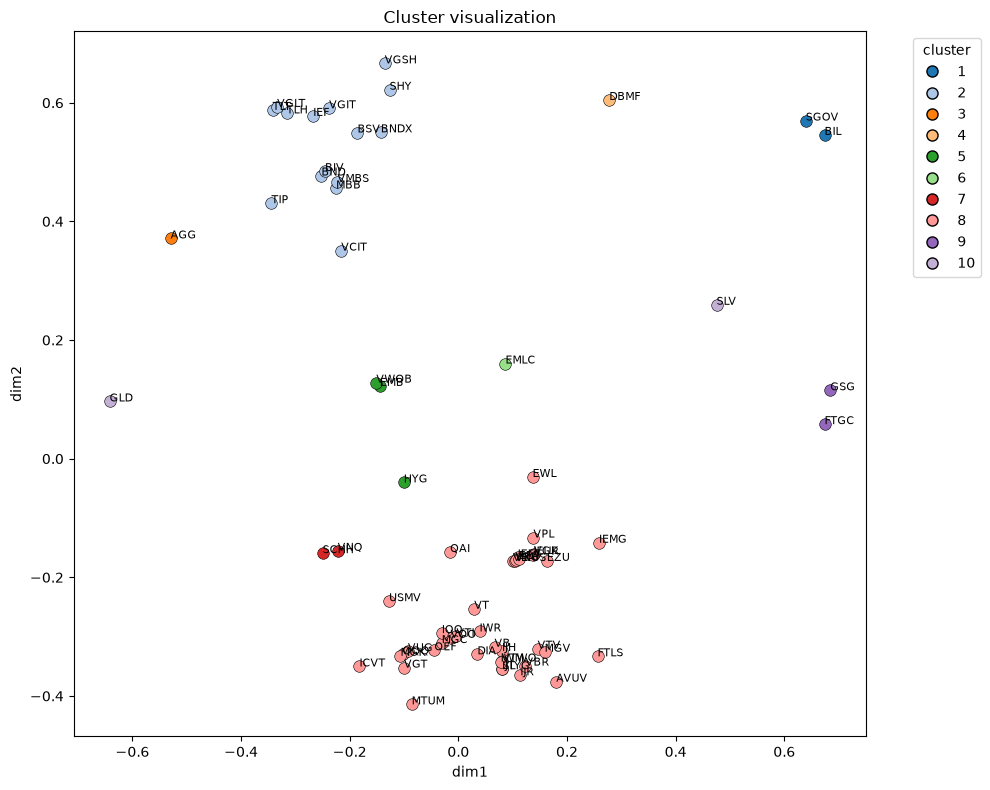

In [2]:
ETF_UNIVERSE_CSV_PATH = "data/etf_universe.csv"

# get clusters (and representatives) from the universe CSV
selected_tickers, clusters = cluster_select_representatives_from_csv(ETF_UNIVERSE_CSV_PATH, n_clusters=10)

print('Found', sum(len(v) for v in clusters.values()), 'tickers across', len(clusters), 'clusters')

# Build aligned price matrix for all tickers in the clusters (inner join on dates)
tickers = sorted([t for members in clusters.values() for t in members])
start_date = '2012-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
prices = pd.concat([load_data(t, start_date, end_date)['adj close'].rename(t) for t in tickers], axis=1, join='inner')
returns = prices.pct_change().dropna()

# Visualize clusters using the returns correlation (MDS embedding)
fig, ax = visualize_clusters(clusters, returns=returns)


### Common window / Optimization / Portfolio construction using the tickers from the clustering

In [3]:
# common window for selected_tickers tickers
min_window, max_window = common_window(selected_tickers)

start_date = "2012-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

print("Min common start date:", min_window, "Max common end date:", max_window)
    
portfolios = build_portfolios(selected_tickers, start_date, end_date)

Min common start date: 2020-06-01 00:00:00 Max common end date: 2026-07-10 00:00:00


### Backtest with historical data using the weights given by optimization 

- min_variance
- equal_weights
- max_sharpie
- market_cap

In [4]:
# Backtest with historical data (min-variance, max-sharpe, market-cap (VT), equal-weight)
from helpers.backtest import backtest_portfolio

# compute portfolio value series for each strategy
min_variance = backtest_portfolio(portfolios["min_variance"], start_value=10_000.0)
max_sharpe  = backtest_portfolio(portfolios["max_sharpe"],  start_value=10_000.0)
market_cap  = backtest_portfolio(portfolios["market_cap"],  start_value=10_000.0)
equal_weight = backtest_portfolio(portfolios["equal_weight"], start_value=10_000.0)

# merge into a single DataFrame for comparison
backtest_results = pd.concat(
    [
        min_variance.rename("min_variance"),
        max_sharpe.rename("max_sharpe"),
        market_cap.rename("market_cap"),
        equal_weight.rename("equal_weight"),
    ],
    axis=1,
)
backtest_results

,min_variance,max_sharpe,market_cap,equal_weight
date,,,,
2020-07-02,10012.773613,10034.437900,10000.0,10027.315265
2020-07-06,10024.487054,10070.079926,10000.0,10069.426850
2020-07-07,10033.116766,10089.181318,10000.0,10040.350536
2020-07-08,10038.464952,10132.814798,10000.0,10075.019611
2020-07-09,10053.642706,10102.292188,10000.0,10056.213941
...,...,...,...,...
2026-07-06,11802.360315,15318.976850,10000.0,16197.859774
2026-07-07,11800.483868,15316.532798,10000.0,16204.919067
2026-07-08,11802.772297,15313.291088,10000.0,16173.169682


### Montecarlo parametric simulation

In [5]:
# Monte Carlo (parametric): simulate returns, rebuild weights, backtest
from helpers.montecarlo import simulate_parametric, rebalance_on_simulation

# simulate ~1 year of daily returns for current tickers
tickers = list(portfolios["min_variance"].columns)
sims_param = simulate_parametric(tickers, n_days=252, n_sims=1, lookback_years=3, seed=42)

# rebuild weights on simulated prices and backtest
W_param, V_param = rebalance_on_simulation(
    sims_param[0], lookback_years=4, freq="BMS", which="min_variance", start_value=10_000.0
)
W_param

,AGG,BND,DBMF,EMLC,GLD,GSG,HYG,SGOV,VNQ,VOO,VT
2000-02-01,0.11895,0.13739,0.17531,0.15789,0.02510,0.03016,0.09612,0.25459,0.0,0.0,0.00449
2000-02-02,0.11895,0.13739,0.17531,0.15789,0.02510,0.03016,0.09612,0.25459,0.0,0.0,0.00449
2000-02-03,0.11895,0.13739,0.17531,0.15789,0.02510,0.03016,0.09612,0.25459,0.0,0.0,0.00449
2000-02-04,0.11895,0.13739,0.17531,0.15789,0.02510,0.03016,0.09612,0.25459,0.0,0.0,0.00449
2000-02-07,0.11895,0.13739,0.17531,0.15789,0.02510,0.03016,0.09612,0.25459,0.0,0.0,0.00449
...,...,...,...,...,...,...,...,...,...,...,...
2000-12-13,0.05635,0.05743,0.04567,0.02568,0.00433,0.00931,0.02263,0.77861,0.0,0.0,0.00000
2000-12-14,0.05635,0.05743,0.04567,0.02568,0.00433,0.00931,0.02263,0.77861,0.0,0.0,0.00000
2000-12-15,0.05635,0.05743,0.04567,0.02568,0.00433,0.00931,0.02263,0.77861,0.0,0.0,0.00000
2000-12-18,0.05635,0.05743,0.04567,0.02568,0.00433,0.00931,0.02263,0.77861,0.0,0.0,0.00000


## Montecarlo Bootstrap

In [6]:
# Monte Carlo (bootstrap): moving-block bootstrap, rebuild weights, backtest
from helpers.montecarlo import simulate_bootstrap, rebalance_on_simulation

sims_boot = simulate_bootstrap(
    tickers, n_days=252, n_sims=3, lookback_years=3, block_size=10, seed=1
)
W_boot, V_boot = rebalance_on_simulation(
    sims_boot[0], lookback_years=4, freq="BMS", which="min_variance", start_value=10_000.0
)

W_boot

,AGG,BND,DBMF,EMLC,GLD,GSG,HYG,SGOV,VNQ,VOO,VT
2000-02-01,0.11487,0.13051,0.07553,0.00067,0.0,0.07539,0.20166,0.33640,0.0,0.04679,0.01817
2000-02-02,0.11487,0.13051,0.07553,0.00067,0.0,0.07539,0.20166,0.33640,0.0,0.04679,0.01817
2000-02-03,0.11487,0.13051,0.07553,0.00067,0.0,0.07539,0.20166,0.33640,0.0,0.04679,0.01817
2000-02-04,0.11487,0.13051,0.07553,0.00067,0.0,0.07539,0.20166,0.33640,0.0,0.04679,0.01817
2000-02-07,0.11487,0.13051,0.07553,0.00067,0.0,0.07539,0.20166,0.33640,0.0,0.04679,0.01817
...,...,...,...,...,...,...,...,...,...,...,...
2000-12-13,0.03243,0.07895,0.04113,0.00000,0.0,0.01021,0.08255,0.75473,0.0,0.00000,0.00000
2000-12-14,0.03243,0.07895,0.04113,0.00000,0.0,0.01021,0.08255,0.75473,0.0,0.00000,0.00000
2000-12-15,0.03243,0.07895,0.04113,0.00000,0.0,0.01021,0.08255,0.75473,0.0,0.00000,0.00000
2000-12-18,0.03243,0.07895,0.04113,0.00000,0.0,0.01021,0.08255,0.75473,0.0,0.00000,0.00000


## Montecarlo aggregation and exporting

In [11]:
from pathlib import Path
from helpers.montecarlo import simulate_and_backtest_portfolios, save_simulations_parquet

# use a local writable path
out_path = Path("output/mc_values.parquet")

df = simulate_and_backtest_portfolios(
    tickers=selected_tickers,
    n_days=252*10,
    n_sims=2,
    lookback_years=3,
    block_size=10,
    seed=1,
    method="bootstrap",
)
save_simulations_parquet(df, str(out_path), engine="pyarrow")



In [10]:
df_loaded = pd.read_parquet(out_path, engine="pyarrow")
df_loaded.head()

df = df_loaded.xs("min_variance", level="strategy", axis=1)

KeyError: 'kind'

### Montecarlo analysis



In [ ]:
summary = quantiles_sim(df)

KeyError: 'Column not found: value'

date
2000-06-01    10291.915867
2000-06-02    10292.364578
2000-06-05    10302.373345
2000-06-06    10303.326402
2000-06-07    10308.522120
                  ...     
2000-08-28    10403.464699
2000-08-29    10434.117969
2000-08-30    10436.660241
2000-08-31    10442.103540
2000-09-01    10444.537705
Freq: B, Name: (1, min_variance), Length: 67, dtype: float64

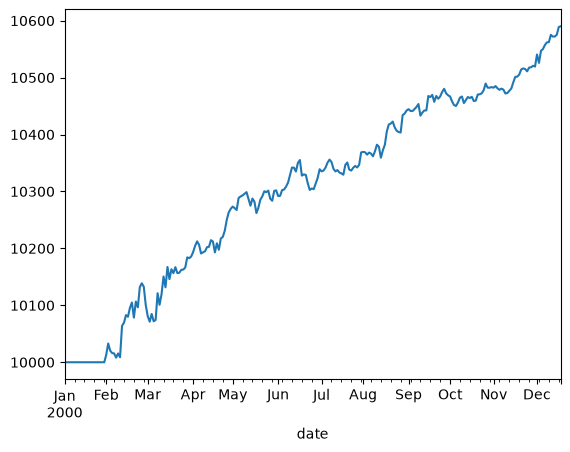

In [ ]:
# single column (one sim, one strategy) -> Series of portfolio value over time
df[(1, "min_variance")]

# same, via .loc
df.loc[:, (1, "min_variance")]

# all strategies for one sim -> sub-DataFrame, columns become just "strategy"
df[1]                       # or df.xs(1, level="sim", axis=1)

# one strategy across all sims -> sub-DataFrame, columns become just "sim"
df.xs("min_variance", level="strategy", axis=1)

# the full "horizon" (all dates) for one sim/strategy path is just the Series itself
df[(1, "min_variance")].plot()

# slice a date range on any of the above
df.loc["2000-06-01":"2000-09-01", (1, "min_variance")]


### Margin Investing - Leverage


In [ ]:
# apply leverage investing to selected portfgolio

portfolio = build_portfolios(selected_tickers, start_date, end_date)

min_variance_weights = portfolio["min_variance"]
max_sharpe_weights  = portfolio["max_sharpe"]
equal_weight_weights = portfolio["equal_weight"]
market_cap_weights  = portfolio["market_cap"]


leverage_backtest_result = leverage_backtest(
    weights = min_variance_weights,
    leverage = 2,
    start_value = 10_000.0,
    band = 0.05,
    spread = 0.01,
)

In [ ]:
leverage_backtest_result

,portfolio_value,gross_exposure,debt,leverage,margin_rate,rebalanced
date,,,,,,
2020-07-02,10025.244448,20025.547226,10000.302778,1.997512,0.0109,False
2020-07-06,10048.368543,20048.974108,10000.605565,1.995247,0.0109,False
2020-07-07,10065.325171,20066.233532,10000.908361,1.993600,0.0109,False
2020-07-08,10075.718737,20076.929903,10001.211166,1.992605,0.0109,False
2020-07-09,10105.771431,20107.285412,10001.513981,1.989683,0.0109,False
...,...,...,...,...,...,...
2026-07-06,11858.971923,23604.720629,11745.748706,1.990453,0.0464,False
2026-07-07,11853.705133,23600.967736,11747.262602,1.991020,0.0464,False
2026-07-08,11856.767901,23605.544594,11748.776694,1.990892,0.0464,False


[Docs](https://pyportfolioopt.readthedocs.io/en/stable/index.html)